# Dataset 2 — Steel Industry Energy Consumption (UCI)  
**Situação**  
A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.  

---

Grupo:
| Nome | RM |
| --- | --- |
| Caio Marinho Pereira | 572873|
<br>


## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 20% dos dados.  
oangeworkflow.svg

### Load_Type e WeekStatus

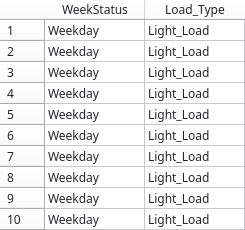

## Import de Bibliotecas
Adiciona as bibliotecas de análise de dados que serão usadas.

In [14]:
import pandas as pd

## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [15]:
dados = pd.read_csv('/content/steel_data.csv')

In [16]:
dados = dados.rename(columns = {'Usage_kWh': 'Consumo_kWh',
                                'Lagging_Current_Reactive.Power_kVarh': 'Corrente_Atrasada_kVarh',
                                'Leading_Current_Reactive_Power_kVarh': 'Corrente_Adiantada_kVarh',
                                'Lagging_Current_Power_Factor' : 'Fator_Potencia_Atrasada',
                                'Leading_Current_Power_Factor': 'Fator_Potencia_Adiantada',
                                'WeekStatus': 'Status_Semana',
                                'Day_of_week': 'Dia_Semana',
                                'Load_Type': 'Nivel_Carga'})

# Análise Exploratória
Processo inicial, responsável por investigar o conjunto de dados, resumir suas características principais e descobrir padrões.

Visualizar os primeiros registros

In [17]:
dados.head()

,Consumo_kWh,Corrente_Atrasada_kVarh,Corrente_Adiantada_kVarh,Fator_Potencia_Atrasada,Fator_Potencia_Adiantada,Status_Semana,Dia_Semana,Nivel_Carga
0,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


Verificar a dimensão do dataframe

In [18]:
print(f"O número de registros do dataframe é: {dados.shape[0]}")
print(f"O número de atributos do dataframe é: {dados.shape[1]}")

O número de registros do dataframe é: 7008
O número de atributos do dataframe é: 8


Verificar informações sobre o formato dos dados

In [19]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Consumo_kWh               7008 non-null   float64
 1   Corrente_Atrasada_kVarh   7008 non-null   float64
 2   Corrente_Adiantada_kVarh  7008 non-null   float64
 3   Fator_Potencia_Atrasada   7008 non-null   float64
 4   Fator_Potencia_Adiantada  7008 non-null   float64
 5   Status_Semana             7008 non-null   object 
 6   Dia_Semana                7008 non-null   object 
 7   Nivel_Carga               7008 non-null   object 
dtypes: float64(5), object(3)
memory usage: 438.1+ KB


Verificar estatísticas descritivas das colunas numéricas

In [20]:
dados.describe()

,Consumo_kWh,Corrente_Atrasada_kVarh,Corrente_Adiantada_kVarh,Fator_Potencia_Atrasada,Fator_Potencia_Adiantada
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


## Operações e Novos DataFrames
Realiza operações, como definição de limites, e cria um novo dataframe para cada uma.

### Maior consumo registrado

In [21]:
max_consumo = dados['Consumo_kWh'].max()
print(f"O maior consumo registrado é de: {max_consumo:.3f} kWh")

O maior consumo registrado é de: 153.140 kWh


### Limiar de 75% desse máximo
Define um limite superior para o Consumo, com base nos 25% valores mais altos

In [22]:
limiar_75 = max_consumo * .75
print(f"O limiar de 75% do consumo máximo equivale a: {limiar_75:.3f} kWh")

O limiar de 75% do consumo máximo equivale a: 114.855 kWh


DataFrame com registros de consumo acima desse limiar

In [23]:
df_consumo_75 = dados[dados['Consumo_kWh'] > limiar_75]
df_consumo_75['Consumo_kWh'].head()

,Consumo_kWh
2,120.42
62,118.22
100,129.13
108,117.07
159,139.57


Quantidade e porcentagem de registros acima do limiar

In [24]:
print(f"A quantidade de registros acima do limiar é de: {df_consumo_75.shape[0]}")
porcent_75 = (df_consumo_75.shape[0] / dados.shape[0]) * 100
print(f"Essa quantidade representa {porcent_75:.2f}% de registros do consumo total")

A quantidade de registros acima do limiar é de: 129
Essa quantidade representa 1.84% de registros do consumo total


Quantos registros acima do linear pertencem à categoria Maximum Load

In [25]:
# Filtrar quais valores acima do limiar são Maximum_Load
mask = (dados['Nivel_Carga'] == 'Maximum_Load').reindex(df_consumo_75.index)
df_linear_maxload = df_consumo_75[mask]
df_linear_maxload[['Consumo_kWh', 'Nivel_Carga']].head()

,Consumo_kWh,Nivel_Carga
2,120.42,Maximum_Load
159,139.57,Maximum_Load
208,125.10,Maximum_Load
295,129.85,Maximum_Load
342,140.04,Maximum_Load


In [26]:
# contagem
print(f"A quantidade de registros acima do limiar que pertencem à categoria Maximum_Load é de: {df_linear_maxload.shape[0]} registros")
porcent_maxload = (df_linear_maxload.shape[0] / dados.shape[0]) * 100
print(f"Essa quantidade representa {porcent_maxload:.2f}% de registros do consumo total")

A quantidade de registros acima do limiar que pertencem à categoria Maximum_Load é de: 62 registros
Essa quantidade representa 0.88% de registros do consumo total


### Fator de Potência Atrasada
Limite para representar valores mais baixos. Esse limite foi escolhido levando em consideração os 5% menores valores de Fator de Potência Atrasada.

In [27]:
limite_inf = dados["Fator_Potencia_Atrasada"].quantile(0.05)
print(limite_inf)

46.8635


In [28]:
df_pot_lim = dados[dados['Fator_Potencia_Atrasada'] < limite_inf]
df_pot_lim['Fator_Potencia_Atrasada'].head()

,Fator_Potencia_Atrasada
12,46.82
22,43.51
52,41.48
87,45.99
138,40.62


Registros com potencia atrasada baixa e, simultaneamente, consumo alto

In [29]:
df_baixa_pot_alto_consumo = dados[(dados['Fator_Potencia_Atrasada'] < limite_inf) & (dados['Consumo_kWh'] > limiar_75)]
df_baixa_pot_alto_consumo[['Fator_Potencia_Atrasada', 'Consumo_kWh']].head()

,Fator_Potencia_Atrasada,Consumo_kWh


### Porquê o conjunto Consumo Elevado e Fator de Potência Abaixo do Limite é importante:

Registros com consumo elevado e fator de potência baixo merecem maior atenção porque combinam uma condição de alta demanda de energia com um fator de potência menor, o que pode indicar uma utilização menos eficiente da energia elétrica e exigir uma análise de gestão de energia. Neste conjunto de dados, entretanto, nenhum registro apresentou, simultaneamente, consumo acima de 75% do máximo e fator de potência atrasada abaixo do limite. Portanto, não foram identificadas ocorrências que atendam simultaneamente aos dois critérios na amostra analisada.